# Técnicas para Melhorar Algoritmos de Aprendizagem
### Disciplina: Inteligência Artificial — Graduação em Ciência da Computação

---

## Objetivos da Aula

Ao final desta aula, você será capaz de:
- Partir de um modelo **baseline** e melhorá-lo sistematicamente
- Preparar dados corretamente: normalização, encoding e **balanceamento de classes (SMOTE)**
- Aplicar **validação cruzada** estratificada para estimativas robustas
- Controlar overfitting com **regularização L1/L2** e **poda de árvores**
- Comparar **Grid Search**, **Random Search** e **Otimização Bayesiana (Optuna)**
- Usar **Boosting (XGBoost)** e comparar com os modelos anteriores
- Construir um **quadro comparativo final** de todas as técnicas

---

## Dataset: Diagnóstico de Doença Cardíaca (UCI Heart Disease)

Usaremos o mesmo dataset ao longo de **toda** a aula para que as técnicas sejam comparáveis entre si.

| Feature | Descrição | Tipo |
|---|---|---|
| `age` | Idade | Numérico |
| `sex` | Sexo (1=M, 0=F) | Binário |
| `cp` | Tipo de dor no peito (0–3) | Categórico |
| `trestbps` | Pressão arterial em repouso | Numérico |
| `chol` | Colesterol sérico | Numérico |
| `fbs` | Glicemia em jejum > 120 mg/dl | Binário |
| `restecg` | Resultado do eletrocardiograma (0–2) | Categórico |
| `thalach` | Frequência cardíaca máxima | Numérico |
| `exang` | Angina induzida por exercício | Binário |
| `oldpeak` | Depressão do ST pelo exercício | Numérico |
| `slope` | Inclinação do segmento ST (0–2) | Ordinal |
| `ca` | Nº de vasos principais (0–3) | Numérico |
| `thal` | Talassemia (0–3) | Categórico |
| **`target`** | **Doença cardíaca (1=sim, 0=não)** | **Alvo** |

## 1. Configuração do Ambiente

In [ ]:
# Instala dependências não inclusas no Colab
!pip install optuna xgboost imbalanced-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    cross_val_score, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay
)

# Balanceamento
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Boosting
from xgboost import XGBClassifier

# Otimização Bayesiana
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')
print('Ambiente configurado!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 21.7 MB/s eta 0:00:00
Ambiente configurado!


## 2. Carregando e Entendendo o Dataset

In [ ]:
# Carrega o dataset via pacote oficial do UCI (mais confiável que URLs diretas)
!pip install ucimlrepo -q

from ucimlrepo import fetch_ucirepo

# ID 45 = Heart Disease (Cleveland) — fonte oficial UCI
heart_disease = fetch_ucirepo(id=45)

# Monta o DataFrame unindo features e alvo
df = heart_disease.data.features.copy()
df['target'] = heart_disease.data.targets.values.ravel()

# Converte para binário: 0 = saudável, 1 = doença (qualquer grau)
df['target'] = (df['target'] > 0).astype(int)

# Remove as poucas linhas com valores faltantes (ca e thal têm alguns NaN)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Shape: {df.shape}')
print(f'Colunas: {list(df.columns)}')
print(f'Valores faltantes restantes: {df.isnull().sum().sum()}')
print(f'\nDistribuição do alvo:')
vc = df['target'].value_counts()
print(f'  Saudável (0): {vc[0]} ({vc[0]/len(df):.1%})')
print(f'  Doente   (1): {vc[1]} ({vc[1]/len(df):.1%})')
df.head()

Shape: (297, 14)
Colunas: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Valores faltantes restantes: 0

Distribuição do alvo:
  Saudável (0): 160 (53.9%)
  Doente   (1): 137 (46.1%)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


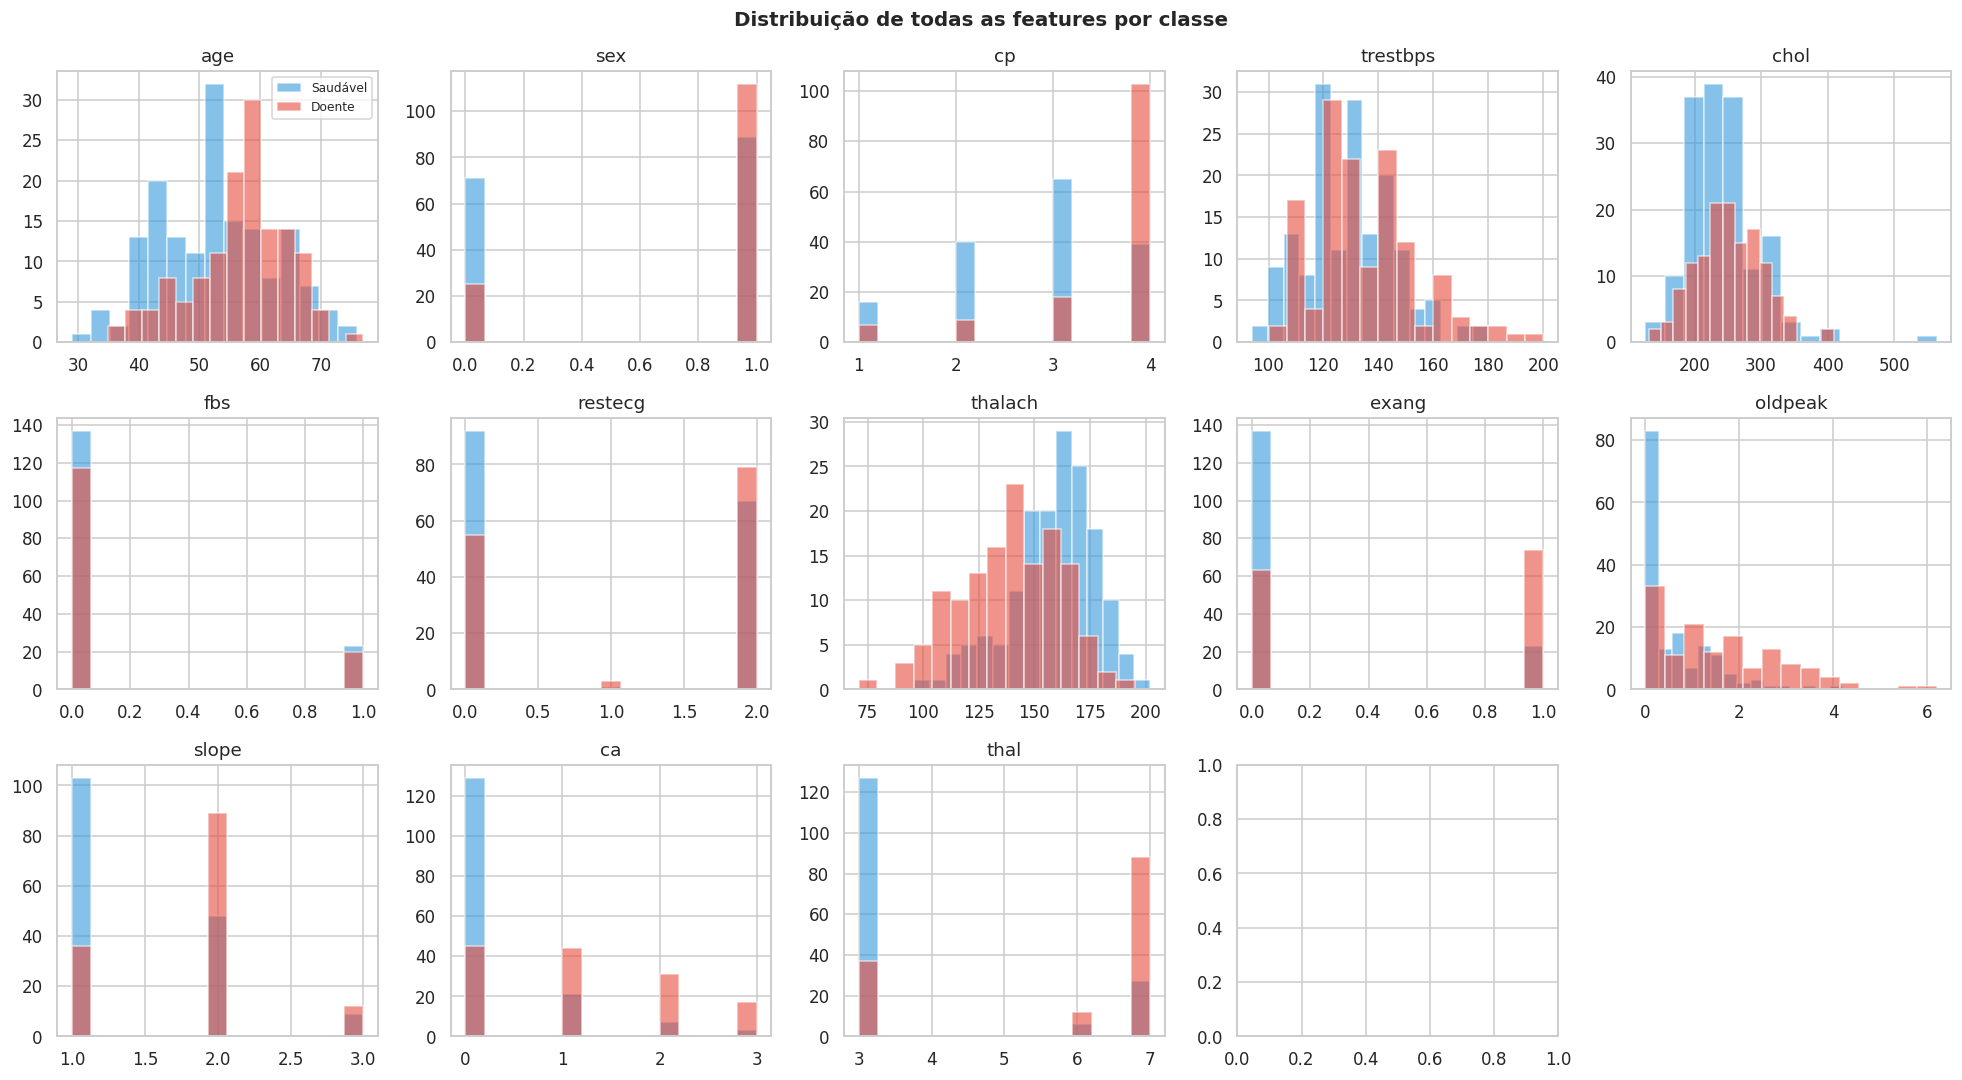

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('Distribuição de todas as features por classe', fontsize=13, fontweight='bold')
axes = axes.flatten()

cores = {0: '#3498db', 1: '#e74c3c'}
for i, col in enumerate(df.columns[:-1]):
    for classe, cor in cores.items():
        label = 'Saudável' if classe == 0 else 'Doente'
        axes[i].hist(df[df['target']==classe][col], bins=15,
                     alpha=0.6, color=cor, label=label, edgecolor='white')
    axes[i].set_title(col); axes[i].set_xlabel('')
    if i == 0: axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## 3. Modelo Baseline — Sem Nenhuma Técnica de Melhoria

Antes de aplicar qualquer técnica, estabelecemos o **baseline**: o desempenho do modelo "cru", sem pré-processamento nem tuning. Toda melhoria posterior será comparada a este ponto de partida.

> **Regra de ouro**: nunca otimize sem saber de onde você está partindo.

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

X_tr, X_ts, y_tr, y_ts = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline: Decision Tree sem qualquer configuração
baseline = DecisionTreeClassifier(random_state=42)
baseline.fit(X_tr, y_tr)
y_pred_base = baseline.predict(X_ts)

acc_base  = accuracy_score(y_ts, y_pred_base)
f1_base   = f1_score(y_ts, y_pred_base)
auc_base  = roc_auc_score(y_ts, baseline.predict_proba(X_ts)[:,1])

print('=== BASELINE (Decision Tree, sem pré-processamento, sem tuning) ===')
print(f'  Acurácia : {acc_base:.4f}')
print(f'  F1-Score : {f1_base:.4f}')
print(f'  AUC-ROC  : {auc_base:.4f}')

# Dicionário que acumulará todos os resultados
resultados = {'Baseline (DT bruto)': (acc_base, f1_base, auc_base)}

=== BASELINE (Decision Tree, sem pré-processamento, sem tuning) ===
  Acurácia : 0.7833
  F1-Score : 0.7547
  AUC-ROC  : 0.7917


---
## 4. Técnica 1 — Qualidade dos Dados

### 4.1 Normalização e Padronização

Modelos baseados em distância (SVM, KNN, regressão logística) são **muito sensíveis** à escala das features. Uma feature com valores 0–500 domina outra com valores 0–1 mesmo que a segunda seja mais informativa.

| Técnica | Fórmula | Quando usar |
|---|---|---|
| **Min-Max Scaling** | $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$ | Resultado em [0,1]; sensível a outliers |
| **Z-Score (StandardScaler)** | $x' = \frac{x - \mu}{\sigma}$ | Média 0, desvio 1; robusto para a maioria dos modelos |

> **Atenção**: o scaler deve ser **ajustado apenas no treino** e depois aplicado no teste — nunca o contrário (isso causaria *data leakage*).

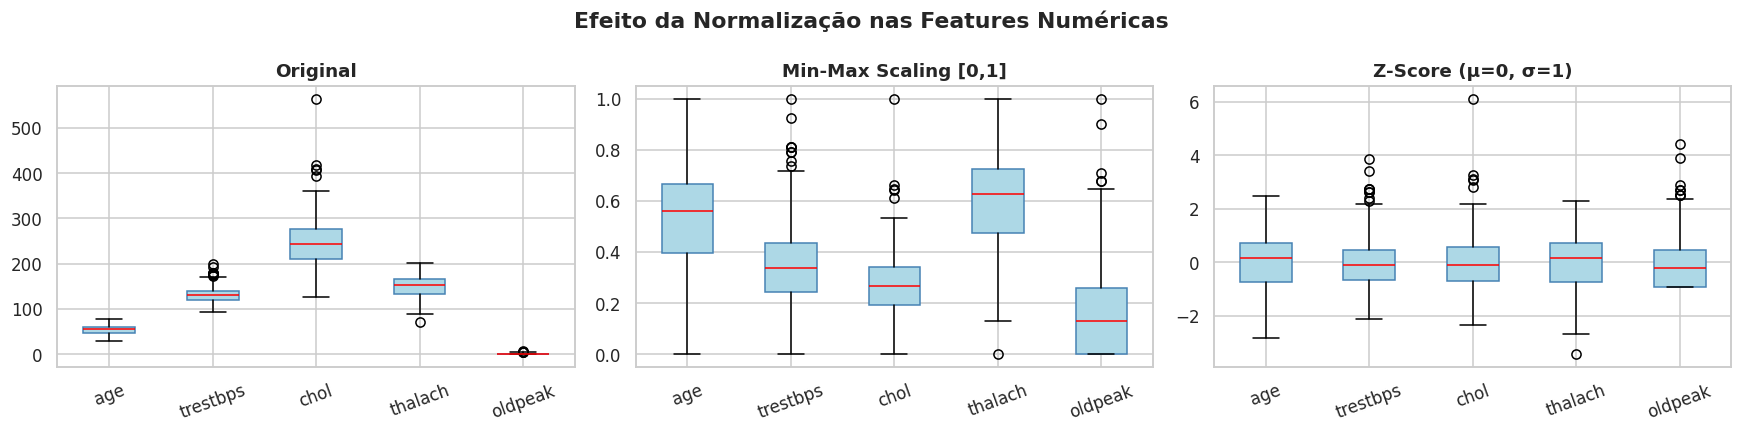

In [ ]:
# Visualiza o efeito da normalização
features_numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

scaler_mm = MinMaxScaler()
scaler_zs = StandardScaler()
X_mm = pd.DataFrame(scaler_mm.fit_transform(X[features_numericas]), columns=features_numericas)
X_zs = pd.DataFrame(scaler_zs.fit_transform(X[features_numericas]), columns=features_numericas)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Efeito da Normalização nas Features Numéricas', fontweight='bold')

for ax, dados, titulo in [
    (axes[0], X[features_numericas],  'Original'),
    (axes[1], X_mm,                   'Min-Max Scaling [0,1]'),
    (axes[2], X_zs,                   'Z-Score (μ=0, σ=1)'),
]:
    ax.boxplot(dados.values, labels=dados.columns, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='steelblue'),
               medianprops=dict(color='red'))
    ax.set_title(titulo, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

Sem normalização       → AUC média: 0.8912 ± 0.0419
Min-Max Scaling        → AUC média: 0.8986 ± 0.0442
Z-Score Scaling        → AUC média: 0.8937 ± 0.0401


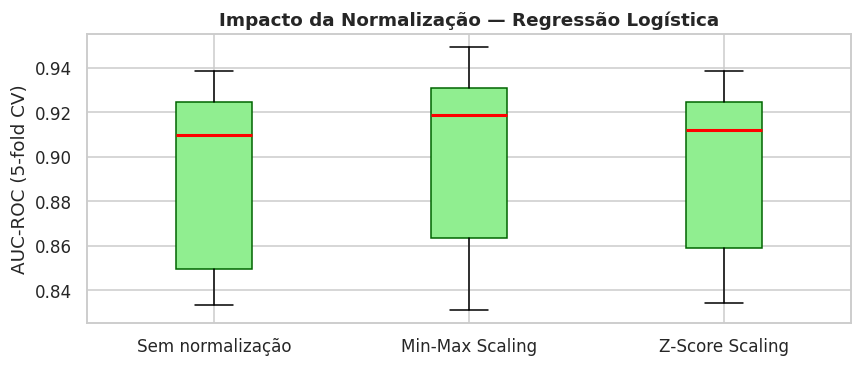

In [ ]:
# Compara impacto da normalização em um modelo sensível à escala (Logistic Regression)
from sklearn.linear_model import LogisticRegression

resultados_scaling = {}
for nome, scaler in [
    ('Sem normalização',    None),
    ('Min-Max Scaling',     MinMaxScaler()),
    ('Z-Score Scaling',     StandardScaler()),
]:
    if scaler:
        pipe = Pipeline([('scaler', scaler),
                         ('clf', LogisticRegression(max_iter=1000, random_state=42))])
    else:
        pipe = LogisticRegression(max_iter=1000, random_state=42)

    scores = cross_val_score(pipe, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42),
                             scoring='roc_auc')
    resultados_scaling[nome] = scores
    print(f'{nome:<22} → AUC média: {scores.mean():.4f} ± {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.boxplot(resultados_scaling.values(), labels=resultados_scaling.keys(),
           patch_artist=True,
           boxprops=dict(facecolor='lightgreen', color='darkgreen'),
           medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('AUC-ROC (5-fold CV)')
ax.set_title('Impacto da Normalização — Regressão Logística', fontweight='bold')
plt.tight_layout(); plt.show()

### 4.2 Balanceamento de Classes com SMOTE

Quando uma classe tem muito menos exemplos que a outra, o modelo tende a **ignorar a minoria** — prever sempre a classe majoritária dá alta acurácia sem nenhum aprendizado real.

O **SMOTE** (*Synthetic Minority Over-sampling TEchnique*) cria exemplos **sintéticos** da classe minoritária interpolando entre exemplos reais vizinhos:

```
Ponto sintético = Ponto A + λ × (Ponto B − Ponto A),   λ ∈ [0, 1]
```

> **Importante**: SMOTE deve ser aplicado **somente no conjunto de treino**, nunca no teste.

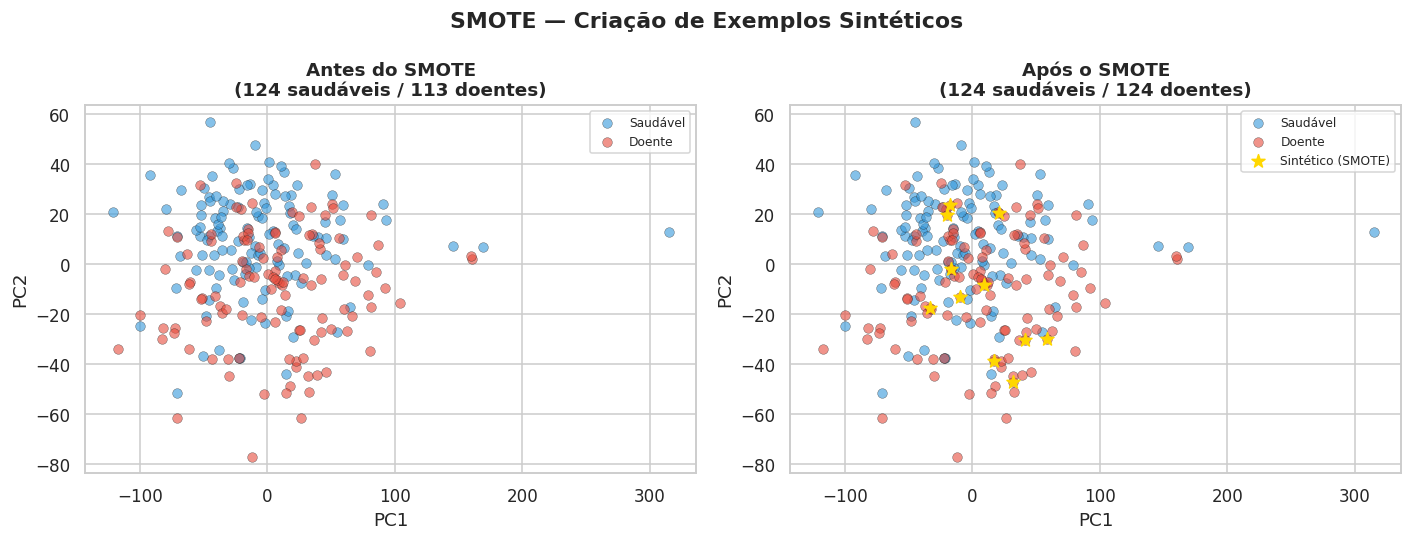

Treino original: {0: 124, 1: 113}
Após SMOTE:      {0: 124, 1: 124}


In [ ]:
from sklearn.decomposition import PCA

# Visualização do SMOTE em 2D (via PCA)
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_tr, y_tr)

pca = PCA(n_components=2, random_state=42)
X_pca_orig = pca.fit_transform(X_tr)
X_pca_sm   = pca.transform(X_sm)

# Identifica quais pontos são sintéticos (os que não existiam no original)
n_orig = len(X_tr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('SMOTE — Criação de Exemplos Sintéticos', fontweight='bold')

for ax, X_plot, y_plot, titulo, n_sinteticos in [
    (ax1, X_pca_orig, y_tr.values, f'Antes do SMOTE\n({y_tr.value_counts()[0]} saudáveis / {y_tr.value_counts()[1]} doentes)', 0),
    (ax2, X_pca_sm,   y_sm,        f'Após o SMOTE\n({(y_sm==0).sum()} saudáveis / {(y_sm==1).sum()} doentes)', n_orig),
]:
    cores_map = {0: '#3498db', 1: '#e74c3c'}
    for classe in [0, 1]:
        mask = y_plot == classe
        label = 'Saudável' if classe == 0 else 'Doente'
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1],
                   c=cores_map[classe], label=label, alpha=0.6, edgecolors='k', linewidths=0.3, s=40)
    if n_sinteticos > 0:
        sint_mask = (y_plot[n_sinteticos:] == 1)
        ax.scatter(X_plot[n_sinteticos:][sint_mask, 0],
                   X_plot[n_sinteticos:][sint_mask, 1],
                   c='gold', marker='*', s=80, label='Sintético (SMOTE)', zorder=5)
    ax.set_title(titulo, fontweight='bold')
    ax.legend(fontsize=8); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.tight_layout(); plt.show()

print(f'Treino original: {y_tr.value_counts().to_dict()}')
print(f'Após SMOTE:      {pd.Series(y_sm).value_counts().to_dict()}')

In [ ]:
# Compara modelos com e sem SMOTE
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_sem_smote = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])
pipe_com_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42)),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42))
])

scores_sem = cross_val_score(pipe_sem_smote, X, y, cv=skf, scoring='f1')
scores_com = cross_val_score(pipe_com_smote, X, y, cv=skf, scoring='f1')

print(f'Sem SMOTE → F1: {scores_sem.mean():.4f} ± {scores_sem.std():.4f}')
print(f'Com SMOTE → F1: {scores_com.mean():.4f} ± {scores_com.std():.4f}')

# Treina versão final para o quadro comparativo
pipe_com_smote.fit(X_tr, y_tr)
y_pred_smote = pipe_com_smote.predict(X_ts)
acc_s  = accuracy_score(y_ts, y_pred_smote)
f1_s   = f1_score(y_ts, y_pred_smote)
auc_s  = roc_auc_score(y_ts, pipe_com_smote.predict_proba(X_ts)[:,1])
resultados['LR + Scaling + SMOTE'] = (acc_s, f1_s, auc_s)
print(f'\nResultado no teste → Acc: {acc_s:.4f}  F1: {f1_s:.4f}  AUC: {auc_s:.4f}')

Sem SMOTE → F1: 0.7960 ± 0.0453
Com SMOTE → F1: 0.7978 ± 0.0467

Resultado no teste → Acc: 0.8833  F1: 0.8627  AUC: 0.9375


---
## 5. Técnica 2 — Validação Robusta

### Por que um único train/test split é insuficiente?

Com apenas uma divisão, a acurácia estimada depende de **quais exemplos caíram no teste por acaso**. Ela pode ser otimista ou pessimista dependendo do sorteio.

### K-Fold Cross-Validation

Divide os dados em K partes (*folds*). O modelo é treinado K vezes: cada vez usando K-1 folds para treino e 1 fold para teste.

```
K=5:
Fold 1: [TESTE] [train] [train] [train] [train]
Fold 2: [train] [TESTE] [train] [train] [train]
Fold 3: [train] [train] [TESTE] [train] [train]
Fold 4: [train] [train] [train] [TESTE] [train]
Fold 5: [train] [train] [train] [train] [TESTE]
                    ↓
     Média dos 5 scores → estimativa robusta
```

### Stratified K-Fold

Garante que **cada fold preserva a proporção original das classes**. Essencial para datasets desbalanceados.

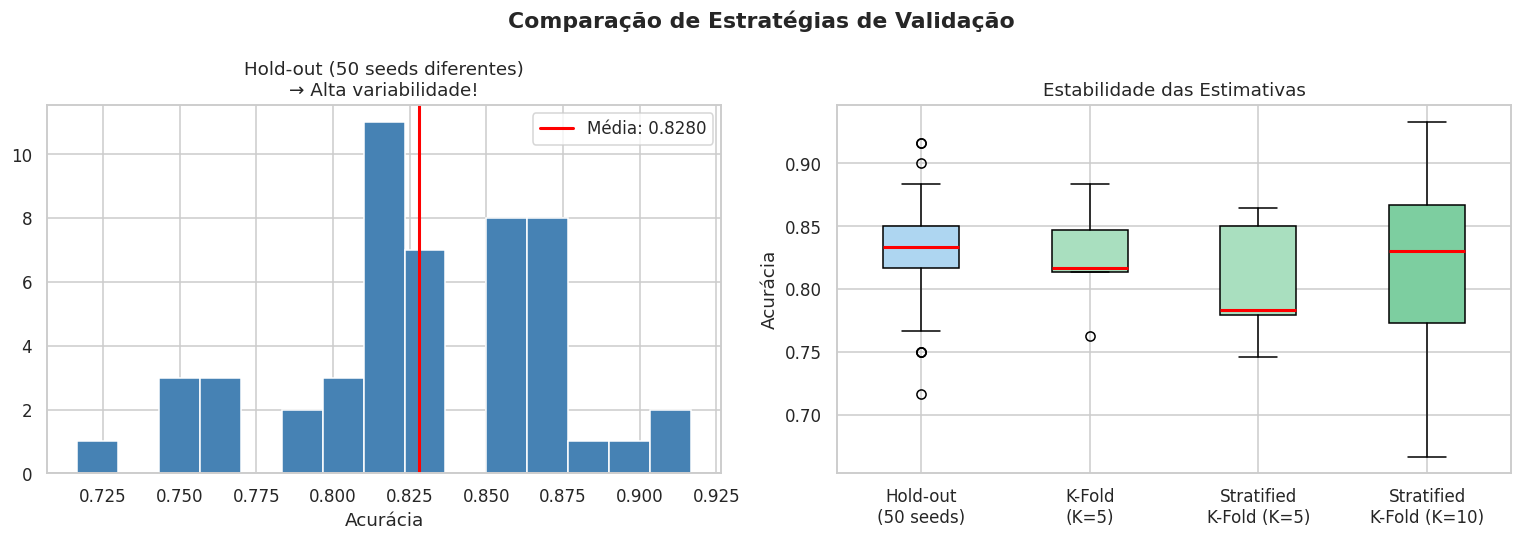

Hold-out (50 seeds):    média=0.8280  std=0.0424
K-Fold (K=5):           média=0.8247  std=0.0400
Stratified K-Fold (5):  média=0.8046  std=0.0451
Stratified K-Fold (10): média=0.8184  std=0.0761


In [ ]:
# Demonstração visual: hold-out vs K-Fold vs Stratified K-Fold
modelo_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 20 repetições de hold-out com diferentes seeds
accs_holdout = []
for seed in range(50):
    Xtr, Xts, ytr, yts = train_test_split(X, y, test_size=0.2, random_state=seed)
    modelo_cv.fit(Xtr, ytr)
    accs_holdout.append(accuracy_score(yts, modelo_cv.predict(Xts)))

scores_kfold    = cross_val_score(modelo_cv, X, y, cv=KFold(5, shuffle=True, random_state=42))
scores_skfold   = cross_val_score(modelo_cv, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42))
scores_skfold10 = cross_val_score(modelo_cv, X, y, cv=StratifiedKFold(10, shuffle=True, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparação de Estratégias de Validação', fontweight='bold')

# Variabilidade do hold-out
axes[0].hist(accs_holdout, bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(accs_holdout), color='red', linewidth=2, label=f'Média: {np.mean(accs_holdout):.4f}')
axes[0].set_title('Hold-out (50 seeds diferentes)\n→ Alta variabilidade!')
axes[0].set_xlabel('Acurácia'); axes[0].legend()

# Comparação boxplot
dados_box = [accs_holdout, scores_kfold, scores_skfold, scores_skfold10]
labels_box = ['Hold-out\n(50 seeds)', 'K-Fold\n(K=5)', 'Stratified\nK-Fold (K=5)', 'Stratified\nK-Fold (K=10)']
bp = axes[1].boxplot(dados_box, labels=labels_box, patch_artist=True,
               medianprops=dict(color='red', linewidth=2))
cores_box = ['#AED6F1','#A9DFBF','#A9DFBF','#7DCEA0']
for patch, cor in zip(bp['boxes'], cores_box):
    patch.set_facecolor(cor)
axes[1].set_ylabel('Acurácia'); axes[1].set_title('Estabilidade das Estimativas')

plt.tight_layout(); plt.show()

print(f'Hold-out (50 seeds):    média={np.mean(accs_holdout):.4f}  std={np.std(accs_holdout):.4f}')
print(f'K-Fold (K=5):           média={scores_kfold.mean():.4f}  std={scores_kfold.std():.4f}')
print(f'Stratified K-Fold (5):  média={scores_skfold.mean():.4f}  std={scores_skfold.std():.4f}')
print(f'Stratified K-Fold (10): média={scores_skfold10.mean():.4f}  std={scores_skfold10.std():.4f}')

---
## 6. Técnica 3 — Regularização (Controle de Overfitting)

### O Dilema Viés × Variância

| | **Alto Viés** (Underfitting) | **Alta Variância** (Overfitting) |
|---|---|---|
| **Sintoma** | Erra tanto no treino quanto no teste | Acerta no treino, erra muito no teste |
| **Causa** | Modelo simples demais | Modelo complexo demais — memoriza ruído |
| **Gap treino/teste** | Pequeno (ambos ruins) | Grande |
| **Solução** | Mais complexidade, mais features | **Regularização**, mais dados |

A regularização adiciona uma **penalidade de complexidade** à função de perda:

$$\mathcal{L}_{total} = \underbrace{\mathcal{L}_{dados}}_{\text{erro}} + \underbrace{\lambda \cdot \Omega(\mathbf{w})}_{\text{penalidade}}$$

O parâmetro $\lambda$ (no sklearn: `C = 1/λ`) controla o tradeoff — quanto maior, mais simples o modelo.

### 6.1 L1, L2 e Elastic Net

| | L1 (Lasso) | L2 (Ridge) | Elastic Net |
|---|---|---|---|
| **Penalidade** | $\sum\|w_j\|$ | $\sum w_j^2$ | $\alpha\|w\|_1 + (1{-}\alpha)\|w\|_2^2$ |
| **Efeito nos coeficientes** | Zera os irrelevantes | Encolhe todos | Zera alguns, encolhe outros |
| **Seleciona features?** | ✅ Sim | ❌ Não | ✅ Parcialmente |
| **Solver sklearn** | `liblinear` | `lbfgs` | `saga` + `l1_ratio` |

> **Intuição geométrica:** a região permitida pelo L1 é um diamante — a solução ótima tende a cair nos seus vértices, onde algum $w_j = 0$. O L2 é uma esfera — raramente toca os eixos.

### 6.2 Regularização em Árvores — Poda

Em árvores, a regularização controla a **estrutura** da árvore, não pesos numéricos.

**Pré-poda** — impede o crescimento excessivo durante o treino:

| Parâmetro | Efeito |
|---|---|
| `max_depth` | Limita profundidade máxima |
| `min_samples_leaf` | Mínimo de amostras por folha |
| `min_samples_split` | Mínimo de amostras para dividir um nó |

**Pós-poda** — remove galhos desnecessários após o treino completo. O sklearn usa o **Cost-Complexity Pruning**:

$$R_\alpha(T) = R(T) + \alpha \cdot |T|$$

onde $|T|$ é o número de folhas e $\alpha$ (`ccp_alpha`) penaliza árvores grandes. O valor ideal de $\alpha$ é encontrado por validação cruzada.

In [ ]:
scaler_fit = StandardScaler()
X_scaled = scaler_fit.fit_transform(X)

# Treina L1, L2 e Elastic Net com C=0.1 e inspeciona os coeficientes
modelos_reg = {
    'L1 (Lasso)   C=0.1': LogisticRegression(C=0.1, penalty='l1', solver='liblinear',
                                              max_iter=1000, random_state=42),
    'L2 (Ridge)   C=0.1': LogisticRegression(C=0.1, penalty='l2', solver='lbfgs',
                                              max_iter=1000, random_state=42),
    'Elastic Net  C=0.1': LogisticRegression(C=0.1, penalty='elasticnet', solver='saga',
                                              l1_ratio=0.5, max_iter=2000, random_state=42),
}

print(f'{"Feature":<12}', end='')
for nome in modelos_reg:
    print(f'{nome:>22}', end='')
print()
print('-' * 78)

coefs_todos = {}
for nome, modelo in modelos_reg.items():
    modelo.fit(X_scaled, y)
    coefs_todos[nome] = modelo.coef_[0]

for i, feat in enumerate(X.columns):
    print(f'{feat:<12}', end='')
    for nome in modelos_reg:
        val = coefs_todos[nome][i]
        marca = ' ← zero' if abs(val) < 1e-4 else ''
        print(f'{val:>21.4f}{marca if marca else " ":>1}', end='')
    print()

print('-' * 78)
print(f'{"# zeros":<12}', end='')
for nome in modelos_reg:
    n = (np.abs(coefs_todos[nome]) < 1e-4).sum()
    print(f'{n:>22}', end='')
print(f'\n\nL1 elimina features (coef=0); L2 apenas encolhe; Elastic Net é híbrido.')

Feature         L1 (Lasso)   C=0.1    L2 (Ridge)   C=0.1    Elastic Net  C=0.1
------------------------------------------------------------------------------
age                        0.0000 ← zero               0.0122                0.0000 ← zero
sex                        0.1614                0.4196                0.2913 
cp                         0.3305                0.4439                0.3898 
trestbps                   0.0362                0.2434                0.1450 
chol                       0.0000 ← zero               0.1436                0.0385 
fbs                        0.0000 ← zero              -0.1855               -0.0668 
restecg                    0.0659                0.1936                0.1336 
thalach                   -0.2517               -0.3494               -0.3005 
exang                      0.2978                0.3622                0.3236 
oldpeak                    0.2948                0.3084                0.2857 
slope                      0

In [ ]:
configs = [
    # (nome,                    penalty,      solver,      C,     l1_ratio)
    ('Sem regularização C=100', 'l2',        'lbfgs',     100.0,  None),
    ('L2 Ridge   C=1.0',        'l2',        'lbfgs',     1.0,    None),
    ('L2 Ridge   C=0.1',        'l2',        'lbfgs',     0.1,    None),
    ('L2 Ridge   C=0.01',       'l2',        'lbfgs',     0.01,   None),
    ('L1 Lasso   C=1.0',        'l1',        'liblinear', 1.0,    None),
    ('L1 Lasso   C=0.1',        'l1',        'liblinear', 0.1,    None),
    ('L1 Lasso   C=0.01',       'l1',        'liblinear', 0.01,   None),
    ('Elastic Net C=0.1 α=0.5', 'elasticnet','saga',      0.1,    0.5),
]

print(f'{"Configuração":<28} {"AUC-ROC (CV)":>13} {"±std":>7} {"# zeros":>9}')
print('-' * 62)

melhor_auc, melhor_nome, melhor_kwargs = 0, '', {}
for nome, penalty, solver, C, l1_ratio in configs:
    kwargs = dict(C=C, penalty=penalty, solver=solver, max_iter=2000, random_state=42)
    if l1_ratio is not None:
        kwargs['l1_ratio'] = l1_ratio
    pipe_r = Pipeline([('sc', StandardScaler()),
                       ('clf', LogisticRegression(**kwargs))])
    scores = cross_val_score(pipe_r, X, y, cv=skf, scoring='roc_auc')
    pipe_r.fit(X, y)
    n_zeros = (np.abs(pipe_r.named_steps['clf'].coef_[0]) < 1e-4).sum()
    marca = ' ◄ melhor' if scores.mean() > melhor_auc else ''
    if scores.mean() > melhor_auc:
        melhor_auc, melhor_nome, melhor_kwargs = scores.mean(), nome, kwargs
    print(f'{nome:<28} {scores.mean():>13.4f} {scores.std():>7.4f} {n_zeros:>9}{marca}')

# Avalia o melhor no teste e registra
pipe_melhor = Pipeline([('sc', StandardScaler()),
                        ('clf', LogisticRegression(**melhor_kwargs))])
pipe_melhor.fit(X_tr, y_tr)
acc_reg = accuracy_score(y_ts, pipe_melhor.predict(X_ts))
f1_reg  = f1_score(y_ts,  pipe_melhor.predict(X_ts))
auc_reg = roc_auc_score(y_ts, pipe_melhor.predict_proba(X_ts)[:, 1])
resultados[f'LR Reg ({melhor_nome})'] = (acc_reg, f1_reg, auc_reg)
print(f'\nMelhor no teste → Acc: {acc_reg:.4f}  F1: {f1_reg:.4f}  AUC: {auc_reg:.4f}')

Configuração                  AUC-ROC (CV)    ±std   # zeros
--------------------------------------------------------------
Sem regularização C=100             0.8930  0.0393         0 ◄ melhor
L2 Ridge   C=1.0                    0.8937  0.0401         0 ◄ melhor
L2 Ridge   C=0.1                    0.8965  0.0428         0 ◄ melhor
L2 Ridge   C=0.01                   0.8980  0.0424         0 ◄ melhor
L1 Lasso   C=1.0                    0.8914  0.0404         0
L1 Lasso   C=0.1                    0.8929  0.0426         3
L1 Lasso   C=0.01                   0.5000  0.0000        13
Elastic Net C=0.1 α=0.5             0.8933  0.0410         1

Melhor no teste → Acc: 0.8833  F1: 0.8444  AUC: 0.9502


*(as células abaixo demonstram na prática os dois tipos de poda descritos acima)*

In [ ]:
# ── Pré-poda: grade max_depth × min_samples_leaf ──────────────────────────
print('=== Pré-poda: Acurácia no TESTE (max_depth × min_samples_leaf) ===\n')
profundidades = [2, 3, 4, 5, 8, None]
min_leaf_vals = [1, 5, 10, 20]

header = f'{"depth":>7}' + ''.join(f'  leaf={v:>2}' for v in min_leaf_vals)
print(header)
print('-' * len(header))

melhor_pre = (0, None, None)
for depth in profundidades:
    linha = f'{"∞" if depth is None else depth:>7}'
    for min_leaf in min_leaf_vals:
        a = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=min_leaf, random_state=42)
        a.fit(X_tr, y_tr)
        acc = a.score(X_ts, y_ts)
        linha += f'  {acc:.3f}   '
        if acc > melhor_pre[0]:
            melhor_pre = (acc, depth, min_leaf)
    print(linha)

print(f'\nMelhor pré-poda: max_depth={melhor_pre[1]}  min_samples_leaf={melhor_pre[2]}'
      f'  →  acc_teste={melhor_pre[0]:.4f}')

# ── Pós-poda: ccp_alpha via validação cruzada ─────────────────────────────
print('\n=== Pós-poda: escolha de ccp_alpha por validação cruzada ===\n')
arvore_aux = DecisionTreeClassifier(random_state=42)
alphas = arvore_aux.cost_complexity_pruning_path(X_tr, y_tr).ccp_alphas[:-1]
alphas_cv = alphas[::max(1, len(alphas) // 15)]  # ~15 pontos representativos

print(f'{"ccp_alpha":>12} {"acc_CV":>9} {"±std":>7} {"folhas":>8} {"acc_teste":>10}')
print('-' * 52)

melhor_pos = (0, None)
for alpha in alphas_cv:
    a = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    sc = cross_val_score(a, X, y,
                         cv=StratifiedKFold(5, shuffle=True, random_state=42),
                         scoring='accuracy')
    a.fit(X_tr, y_tr)
    acc_ts = a.score(X_ts, y_ts)
    marca = ' ◄' if sc.mean() > melhor_pos[0] else ''
    if sc.mean() > melhor_pos[0]:
        melhor_pos = (sc.mean(), alpha)
    print(f'{alpha:>12.5f} {sc.mean():>9.4f} {sc.std():>7.4f} '
          f'{a.get_n_leaves():>8} {acc_ts:>10.4f}{marca}')

# Avalia o melhor alpha no teste
a_final = DecisionTreeClassifier(ccp_alpha=melhor_pos[1], random_state=42)
a_final.fit(X_tr, y_tr)
print(f'\nMelhor ccp_alpha={melhor_pos[1]:.5f}  '
      f'folhas={a_final.get_n_leaves()}  '
      f'acc_teste={a_final.score(X_ts, y_ts):.4f}  '
      f'(sem poda: {DecisionTreeClassifier(random_state=42).fit(X_tr,y_tr).score(X_ts,y_ts):.4f})')

=== Pré-poda: Acurácia no TESTE (max_depth × min_samples_leaf) ===

  depth  leaf= 1  leaf= 5  leaf=10  leaf=20
-------------------------------------------
      2  0.867     0.867     0.867     0.867   
      3  0.783     0.800     0.800     0.867   
      4  0.783     0.767     0.800     0.867   
      5  0.783     0.817     0.800     0.867   
      8  0.783     0.833     0.800     0.867   
      ∞  0.783     0.833     0.800     0.867   

Melhor pré-poda: max_depth=2  min_samples_leaf=1  →  acc_teste=0.8667

=== Pós-poda: escolha de ccp_alpha por validação cruzada ===

   ccp_alpha    acc_CV    ±std   folhas  acc_teste
----------------------------------------------------
     0.00000    0.7206  0.0269       46     0.7833 ◄
     0.00277    0.7206  0.0269       43     0.7833
     0.00362    0.7205  0.0347       39     0.7833
     0.00389    0.7205  0.0347       37     0.7833
     0.00402    0.7138  0.0354       35     0.8167
     0.00544    0.7271  0.0400       32     0.8167 ◄
     0.0

---
## 7. Técnica 4 — Otimização de Hiperparâmetros

Nenhum algoritmo de ML funciona bem "na caixa". A escolha dos hiperparâmetros certos é crucial.

| Método | Como funciona | Prós | Contras |
|---|---|---|---|
| **Grid Search** | Testa **todas** as combinações | Garante o ótimo no grid | Exponencialmente lento |
| **Random Search** | Amostra **aleatória** do espaço | ~10× mais eficiente | Pode perder o ótimo |
| **Bayesian (Optuna)** | Usa resultados passados para **guiar** a busca | Muito eficiente | Mais complexo de configurar |

> **Regra prática**: Random Search com 50–100 iterações quase sempre supera o Grid Search em datasets reais.

In [ ]:
import time

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [3, 5, 10, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [1, 2, 4],
}
# Grid: 3×4×2×3 = 72 combinações

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# --- Grid Search ---
t0 = time.time()
gs = GridSearchCV(rf_base, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
gs.fit(X_tr, y_tr)
t_gs = time.time() - t0

# --- Random Search ---
t0 = time.time()
rs = RandomizedSearchCV(rf_base, param_grid, n_iter=20, cv=5,
                         scoring='roc_auc', random_state=42, n_jobs=-1)
rs.fit(X_tr, y_tr)
t_rs = time.time() - t0

print(f'Grid Search    → Melhor AUC (CV): {gs.best_score_:.4f}  | Tempo: {t_gs:.1f}s | Combinações testadas: 72')
print(f'Random Search  → Melhor AUC (CV): {rs.best_score_:.4f}  | Tempo: {t_rs:.1f}s | Combinações testadas: 20')
print(f'\nMelhores parâmetros (Grid):   {gs.best_params_}')
print(f'Melhores parâmetros (Random): {rs.best_params_}')

# Avalia no teste
acc_gs = accuracy_score(y_ts, gs.best_estimator_.predict(X_ts))
f1_gs  = f1_score(y_ts, gs.best_estimator_.predict(X_ts))
auc_gs = roc_auc_score(y_ts, gs.best_estimator_.predict_proba(X_ts)[:,1])
resultados['RF + Grid Search'] = (acc_gs, f1_gs, auc_gs)

acc_rs = accuracy_score(y_ts, rs.best_estimator_.predict(X_ts))
f1_rs  = f1_score(y_ts, rs.best_estimator_.predict(X_ts))
auc_rs = roc_auc_score(y_ts, rs.best_estimator_.predict_proba(X_ts)[:,1])
resultados['RF + Random Search'] = (acc_rs, f1_rs, auc_rs)

Grid Search    → Melhor AUC (CV): 0.8935  | Tempo: 88.8s | Combinações testadas: 72
Random Search  → Melhor AUC (CV): 0.8935  | Tempo: 20.6s | Combinações testadas: 20

Melhores parâmetros (Grid):   {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}
Melhores parâmetros (Random): {'n_estimators': 100, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 3}


### 7.1 Otimização Bayesiana com Optuna

O **Optuna** usa um algoritmo de *Tree-structured Parzen Estimator* (TPE) para construir um **modelo probabilístico** de quais regiões do espaço de hiperparâmetros são mais promissoras, concentrando as tentativas nessas regiões.

In [ ]:
def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 300),
        'max_depth':         trial.suggest_int('max_depth', 3, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt','log2']),
    }
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    score = cross_val_score(model, X_tr, y_tr,
                            cv=StratifiedKFold(3, shuffle=True, random_state=42),
                            scoring='roc_auc').mean()
    return score

t0 = time.time()
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)
t_opt = time.time() - t0

print(f'\nOptuna → Melhor AUC (CV): {study.best_value:.4f}  | Tempo: {t_opt:.1f}s | Tentativas: 50')
print(f'Melhores parâmetros: {study.best_params}')

  0%|          | 0/50 [00:00<?, ?it/s]


Optuna → Melhor AUC (CV): 0.8889  | Tempo: 45.4s | Tentativas: 50
Melhores parâmetros: {'n_estimators': 62, 'max_depth': 15, 'min_samples_leaf': 6, 'max_features': 'log2'}


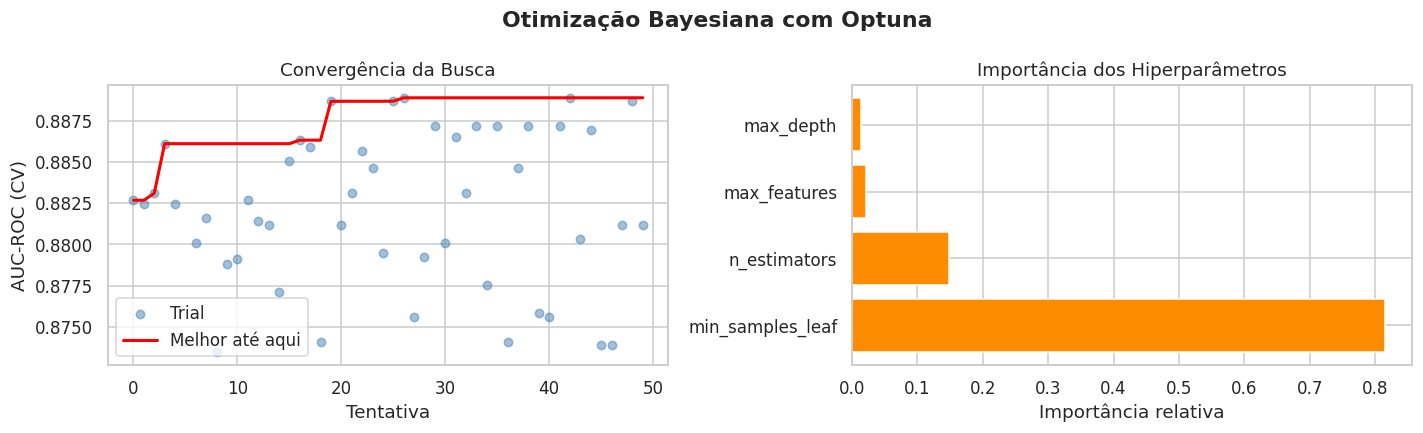

Optuna no teste → Acc: 0.8667  F1: 0.8261  AUC: 0.9664


In [ ]:
# Visualiza a evolução da busca do Optuna
valores = [t.value for t in study.trials]
melhor_ate_agora = np.maximum.accumulate(valores)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Otimização Bayesiana com Optuna', fontweight='bold')

ax1.scatter(range(len(valores)), valores, alpha=0.5, color='steelblue', s=30, label='Trial')
ax1.plot(range(len(melhor_ate_agora)), melhor_ate_agora, color='red',
         linewidth=2, label='Melhor até aqui')
ax1.set_xlabel('Tentativa'); ax1.set_ylabel('AUC-ROC (CV)')
ax1.set_title('Convergência da Busca'); ax1.legend()

# Importância dos hiperparâmetros
try:
    import optuna.visualization as ov
    importances = optuna.importance.get_param_importances(study)
    ax2.barh(list(importances.keys()), list(importances.values()), color='darkorange', edgecolor='white')
    ax2.set_title('Importância dos Hiperparâmetros')
    ax2.set_xlabel('Importância relativa')
except:
    ax2.text(0.5, 0.5, 'Importâncias\n(requer optuna >= 2.6)',
             ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout(); plt.show()

# Avalia melhor modelo Optuna no teste
rf_optuna = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
rf_optuna.fit(X_tr, y_tr)
acc_opt = accuracy_score(y_ts, rf_optuna.predict(X_ts))
f1_opt  = f1_score(y_ts, rf_optuna.predict(X_ts))
auc_opt = roc_auc_score(y_ts, rf_optuna.predict_proba(X_ts)[:,1])
resultados['RF + Optuna (Bayesian)'] = (acc_opt, f1_opt, auc_opt)
print(f'Optuna no teste → Acc: {acc_opt:.4f}  F1: {f1_opt:.4f}  AUC: {auc_opt:.4f}')

---
## 8. Técnica 5 — Ensemble: Boosting

Na aula anterior vimos o **Bagging** (Random Forest): modelos treinados em paralelo e combinados por votação.

O **Boosting** funciona de forma diferente: os modelos são treinados **sequencialmente**, e cada novo modelo foca nos exemplos que o anterior **errou**.

```
BAGGING (paralelo):      BOOSTING (sequencial):

Dados → M1 →┐            Dados → M1 → erros
Dados → M2 →┤ Votação     erros → M2 → erros
Dados → M3 →┘             erros → M3 → ...
                                   ↓
                          Soma ponderada
```

### Principais algoritmos

| Algoritmo | Ideia central |
|---|---|
| **AdaBoost** | Aumenta o peso dos exemplos errados a cada iteração |
| **Gradient Boosting** | Treina cada modelo para corrigir os **resíduos** do anterior |
| **XGBoost** | Gradient Boosting otimizado: regularização L1/L2, paralelismo, missing values |
| **LightGBM** | Ainda mais rápido; cresce a árvore por folha (leaf-wise) |
| **CatBoost** | Especializado em variáveis categóricas |

In [ ]:
# AdaBoost
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # "stumps"
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
ada.fit(X_tr, y_tr)
acc_ada = accuracy_score(y_ts, ada.predict(X_ts))
f1_ada  = f1_score(y_ts, ada.predict(X_ts))
auc_ada = roc_auc_score(y_ts, ada.predict_proba(X_ts)[:,1])
resultados['AdaBoost'] = (acc_ada, f1_ada, auc_ada)

# XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,   # L1
    reg_lambda=1.0,  # L2
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_tr, y_tr)
acc_xgb = accuracy_score(y_ts, xgb.predict(X_ts))
f1_xgb  = f1_score(y_ts, xgb.predict(X_ts))
auc_xgb = roc_auc_score(y_ts, xgb.predict_proba(X_ts)[:,1])
resultados['XGBoost'] = (acc_xgb, f1_xgb, auc_xgb)

print(f'AdaBoost → Acc: {acc_ada:.4f}  F1: {f1_ada:.4f}  AUC: {auc_ada:.4f}')
print(f'XGBoost  → Acc: {acc_xgb:.4f}  F1: {f1_xgb:.4f}  AUC: {auc_xgb:.4f}')

AdaBoost → Acc: 0.8833  F1: 0.8627  AUC: 0.9525
XGBoost  → Acc: 0.8500  F1: 0.8235  AUC: 0.9306


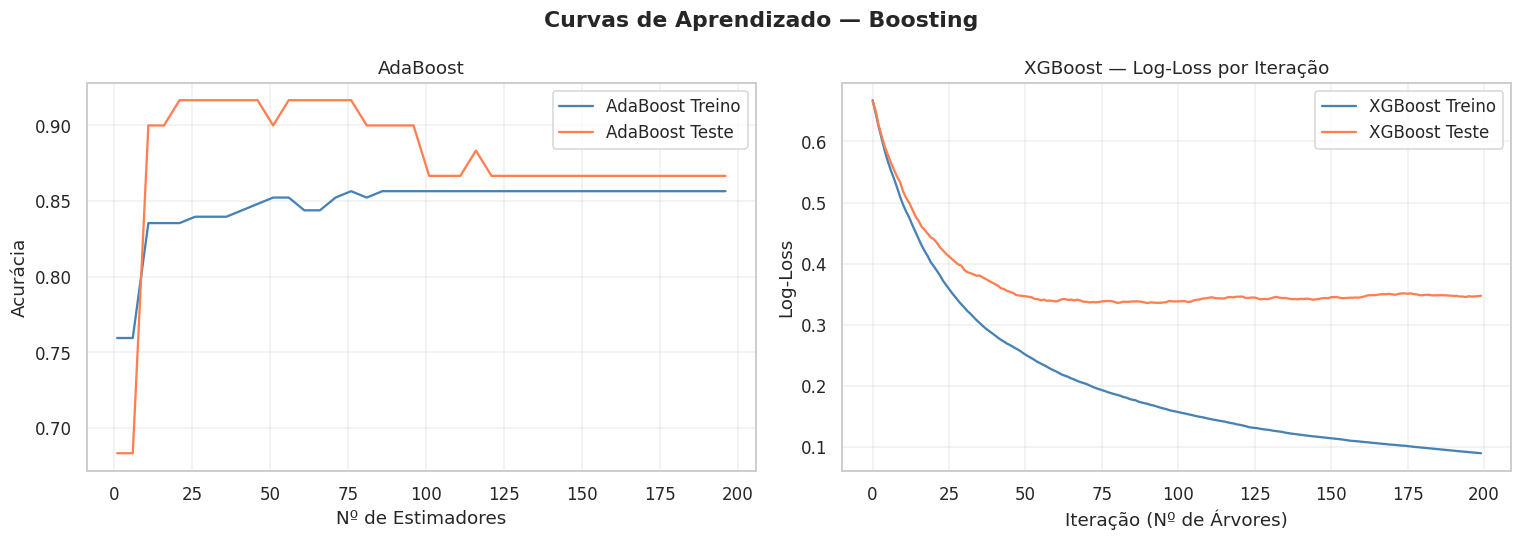

In [ ]:
# Curva de aprendizado do Boosting: performance vs. número de estimadores
n_est_range = range(1, 201, 5)

accs_ada_tr, accs_ada_ts = [], []
for n in n_est_range:
    a = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                           n_estimators=n, learning_rate=0.1, random_state=42)
    a.fit(X_tr, y_tr)
    accs_ada_tr.append(a.score(X_tr, y_tr))
    accs_ada_ts.append(a.score(X_ts, y_ts))

# XGBoost staged scores
xgb_eval = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_eval.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_ts, y_ts)], verbose=False)
xgb_results = xgb_eval.evals_result()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de Aprendizado — Boosting', fontweight='bold')

ax1.plot(n_est_range, accs_ada_tr, color='steelblue', label='AdaBoost Treino')
ax1.plot(n_est_range, accs_ada_ts, color='coral',     label='AdaBoost Teste')
ax1.set_xlabel('Nº de Estimadores'); ax1.set_ylabel('Acurácia')
ax1.set_title('AdaBoost'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(xgb_results['validation_0']['logloss'], color='steelblue', label='XGBoost Treino')
ax2.plot(xgb_results['validation_1']['logloss'], color='coral',     label='XGBoost Teste')
ax2.set_xlabel('Iteração (Nº de Árvores)'); ax2.set_ylabel('Log-Loss')
ax2.set_title('XGBoost — Log-Loss por Iteração'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

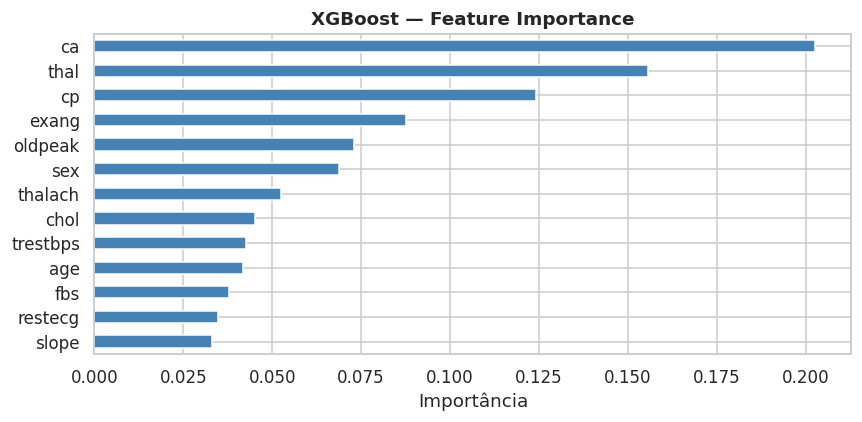

In [ ]:
# Feature importance do XGBoost
xgb_imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
xgb_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('XGBoost — Feature Importance', fontweight='bold')
ax.set_xlabel('Importância')
plt.tight_layout(); plt.show()

---
## 9. Quadro Comparativo Final

Agora vamos comparar **todas as técnicas** aplicadas ao mesmo dataset, partindo do mesmo baseline.

In [ ]:
df_res = pd.DataFrame(resultados, index=['Acurácia','F1-Score','AUC-ROC']).T
df_res = df_res.sort_values('AUC-ROC', ascending=False)

print('=' * 62)
print(f'{"Modelo / Técnica":<30} {"Acurácia":>10} {"F1-Score":>10} {"AUC-ROC":>10}')
print('-' * 62)
for nome, row in df_res.iterrows():
    eh_base = '(baseline)' if 'Baseline' in nome else '          '
    delta_auc = row['AUC-ROC'] - resultados['Baseline (DT bruto)'][2]
    sinal = f'+{delta_auc:.4f}' if delta_auc >= 0 else f'{delta_auc:.4f}'
    print(f'{nome:<30} {row["Acurácia"]:>10.4f} {row["F1-Score"]:>10.4f} '
          f'{row["AUC-ROC"]:>10.4f}  (Δ AUC {sinal})')
print('=' * 62)

Modelo / Técnica                 Acurácia   F1-Score    AUC-ROC
--------------------------------------------------------------
RF + Optuna (Bayesian)             0.8667     0.8261     0.9664  (Δ AUC +0.1748)
RF + Grid Search                   0.8667     0.8261     0.9606  (Δ AUC +0.1690)
RF + Random Search                 0.8667     0.8261     0.9606  (Δ AUC +0.1690)
AdaBoost                           0.8833     0.8627     0.9525  (Δ AUC +0.1609)
LR Reg (L2 Ridge   C=0.01)         0.8833     0.8444     0.9502  (Δ AUC +0.1586)
LR + Scaling + SMOTE               0.8833     0.8627     0.9375  (Δ AUC +0.1458)
XGBoost                            0.8500     0.8235     0.9306  (Δ AUC +0.1389)
Baseline (DT bruto)                0.7833     0.7547     0.7917  (Δ AUC +0.0000)


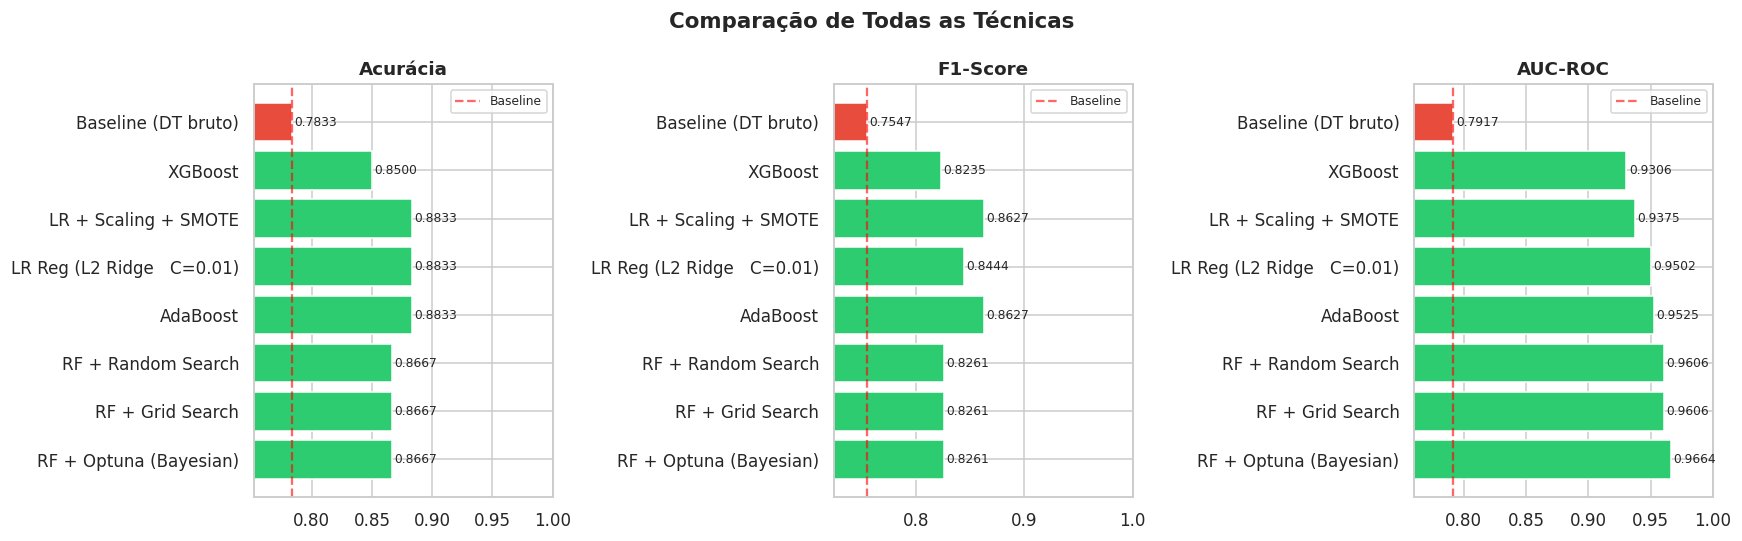

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparação de Todas as Técnicas', fontsize=14, fontweight='bold')

cores_bar = ['#e74c3c' if 'Baseline' in n else '#2ecc71' for n in df_res.index]

for ax, metrica in zip(axes, ['Acurácia','F1-Score','AUC-ROC']):
    bars = ax.barh(df_res.index, df_res[metrica], color=cores_bar, edgecolor='white')
    ax.set_title(metrica, fontweight='bold')
    ax.set_xlim([df_res[metrica].min() * 0.96, 1.0])
    for bar, val in zip(bars, df_res[metrica]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    baseline_val = resultados['Baseline (DT bruto)'][['Acurácia','F1-Score','AUC-ROC'].index(metrica)]
    ax.axvline(baseline_val, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='Baseline')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

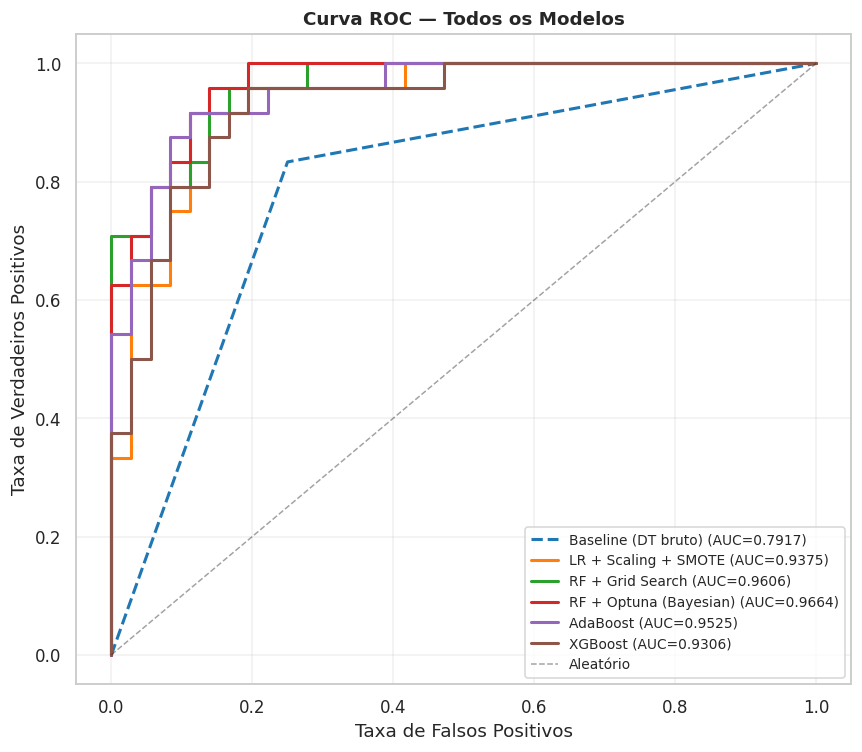

In [ ]:
# Curva ROC de todos os modelos
from sklearn.metrics import roc_curve, auc

modelos_finais = {
    'Baseline (DT bruto)':   (baseline,            X_ts),
    'LR + Scaling + SMOTE':  (pipe_com_smote,       X_ts),
    'RF + Grid Search':      (gs.best_estimator_,   X_ts),
    'RF + Optuna (Bayesian)':(rf_optuna,            X_ts),
    'AdaBoost':              (ada,                  X_ts),
    'XGBoost':               (xgb,                  X_ts),
}

fig, ax = plt.subplots(figsize=(8, 7))
cmap = plt.cm.get_cmap('tab10')

for i, (nome, (modelo, X_eval)) in enumerate(modelos_finais.items()):
    probs = modelo.predict_proba(X_eval)[:,1]
    fpr, tpr, _ = roc_curve(y_ts, probs)
    roc_auc = auc(fpr, tpr)
    ls = '--' if 'Baseline' in nome else '-'
    ax.plot(fpr, tpr, linewidth=2, color=cmap(i), linestyle=ls,
            label=f'{nome} (AUC={roc_auc:.4f})')

ax.plot([0,1],[0,1],'k--', linewidth=1, alpha=0.4, label='Aleatório')
ax.set_xlabel('Taxa de Falsos Positivos'); ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC — Todos os Modelos', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 10. Exercícios Propostos

### Exercício 1 — Pipeline Completo
Construa um único `Pipeline` (ou `ImbPipeline`) que combine:
- StandardScaler
- SMOTE
- XGBoost com os melhores hiperparâmetros encontrados pelo Optuna

Avalie com Stratified K-Fold (10 folds) e compare com o XGBoost sem SMOTE.

In [ ]:
# Exercício 1: Pipeline completo XGBoost + SMOTE
# Seu código aqui


### Exercício 2 — Otimizando o XGBoost com Optuna
Crie um `objective` para o Optuna que otimize o XGBoost, incluindo os parâmetros:
- `learning_rate`: float log-uniforme entre 0.01 e 0.3
- `max_depth`: inteiro entre 3 e 10
- `n_estimators`: inteiro entre 100 e 500
- `subsample`: float entre 0.6 e 1.0
- `reg_alpha` e `reg_lambda`: float log-uniforme entre 1e-3 e 10

Use `n_trials=100` e compare com o XGBoost padrão da seção 8.

In [ ]:
# Exercício 2: Optuna para XGBoost
def objective_xgb(trial):
    params = {
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        # Complete os demais parâmetros aqui
    }
    # Seu código aqui
    pass


### Exercício 3 — Stacking
Implemente um **Stacking Classifier** usando o `StackingClassifier` do sklearn:
- **Base learners**: Logistic Regression, Random Forest, XGBoost
- **Meta-learner**: Logistic Regression

Compare a acurácia e AUC com os modelos individuais.

In [ ]:
from sklearn.ensemble import StackingClassifier

estimadores_base = [
    ('lr',  Pipeline([('sc', StandardScaler()),
                      ('clf', LogisticRegression(max_iter=1000, random_state=42))])),
    ('rf',  RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, use_label_encoder=False,
                           eval_metric='logloss', random_state=42)),
]

# Seu código aqui: crie o StackingClassifier, treine e avalie


### Exercício 4 — Análise de Viés × Variância
Use a biblioteca `mlxtend` para plotar a **decomposição viés-variância** do erro de 3 modelos:
- Decision Tree profunda (overfitting)
- Decision Tree rasa (underfitting)
- Random Forest (ponto ótimo)

```python
!pip install mlxtend -q
from mlxtend.evaluate import bias_variance_decomp
```

In [ ]:
!pip install mlxtend -q
from mlxtend.evaluate import bias_variance_decomp

# Seu código aqui


---
## 11. Resumo: Quando Usar Cada Técnica?

```
PROBLEMA IDENTIFICADO           →  TÉCNICA RECOMENDADA
─────────────────────────────────────────────────────────
Features em escalas diferentes  →  StandardScaler / MinMaxScaler
Classes desbalanceadas          →  SMOTE / class_weight='balanced'
Estimativa de performance ruim  →  Stratified K-Fold
Overfitting (treino >> teste)   →  L1/L2, Dropout, Poda, mais dados
Underfitting (ambos baixos)     →  Modelo mais complexo, mais features
Hiperparâmetros ruins           →  Random Search → Optuna
Modelo individual fraco         →  Random Forest (bagging) / XGBoost (boosting)
Máxima performance necessária   →  Stacking + Optuna
```

In [ ]:
print('=== Resumo dos conceitos desta aula ===')
conceitos = [
    '✓ Baseline: ponto de partida obrigatório antes de qualquer otimização',
    '✓ Normalização: essencial para modelos baseados em distância/gradiente',
    '✓ SMOTE: cria exemplos sintéticos da classe minoritária por interpolação',
    '✓ Stratified K-Fold: estimativa robusta que preserva proporção das classes',
    '✓ L1 (Lasso): zera pesos irrelevantes → seleção implícita de features',
    '✓ L2 (Ridge): distribui pesos pequenos → mais estável',
    '✓ Poda (ccp_alpha): remove galhos que não melhoram a generalização',
    '✓ Grid Search: exaustivo; Random Search: eficiente; Optuna: inteligente',
    '✓ AdaBoost: re-pondera exemplos errados a cada iteração',
    '✓ XGBoost: Gradient Boosting com regularização L1/L2 e otimizações',
    '✓ Stacking: meta-modelo aprende a combinar previsões dos base learners',
]
for c in conceitos:
    print(c)

=== Resumo dos conceitos desta aula ===
✓ Baseline: ponto de partida obrigatório antes de qualquer otimização
✓ Normalização: essencial para modelos baseados em distância/gradiente
✓ SMOTE: cria exemplos sintéticos da classe minoritária por interpolação
✓ Stratified K-Fold: estimativa robusta que preserva proporção das classes
✓ L1 (Lasso): zera pesos irrelevantes → seleção implícita de features
✓ L2 (Ridge): distribui pesos pequenos → mais estável
✓ Poda (ccp_alpha): remove galhos que não melhoram a generalização
✓ Grid Search: exaustivo; Random Search: eficiente; Optuna: inteligente
✓ AdaBoost: re-pondera exemplos errados a cada iteração
✓ XGBoost: Gradient Boosting com regularização L1/L2 e otimizações
✓ Stacking: meta-modelo aprende a combinar previsões dos base learners


---

## Referências

1. Chawla, N. V. et al. (2002). *SMOTE: Synthetic Minority Over-sampling Technique*. JAIR, 16, 321–357.
2. Chen, T. & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD.
3. Akiba, T. et al. (2019). *Optuna: A Next-generation Hyperparameter Optimization Framework*. KDD.
4. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (3ª ed.). O'Reilly.
5. Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer.
6. UCI Heart Disease Dataset: https://archive.ics.uci.edu/ml/datasets/heart+disease

---
*Notebook criado para a disciplina de Inteligência Artificial — Ciência da Computação*